In [1]:
from utils import load_from_pickle

from matplotlib import pyplot as plt
import matplotlib as mpl

# Avoid Type 3 fonts in PDF/PS/SVG
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

# Use built-in mathtext Computer Modern
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'     # Computer Modern for math
mpl.rcParams['font.family'] = 'serif'       # Serif text
mpl.rcParams['font.serif'] = ['DejaVu Serif']  # fallback text font

/home/anath/anaconda3/envs/llm/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/anath/anaconda3/envs/llm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


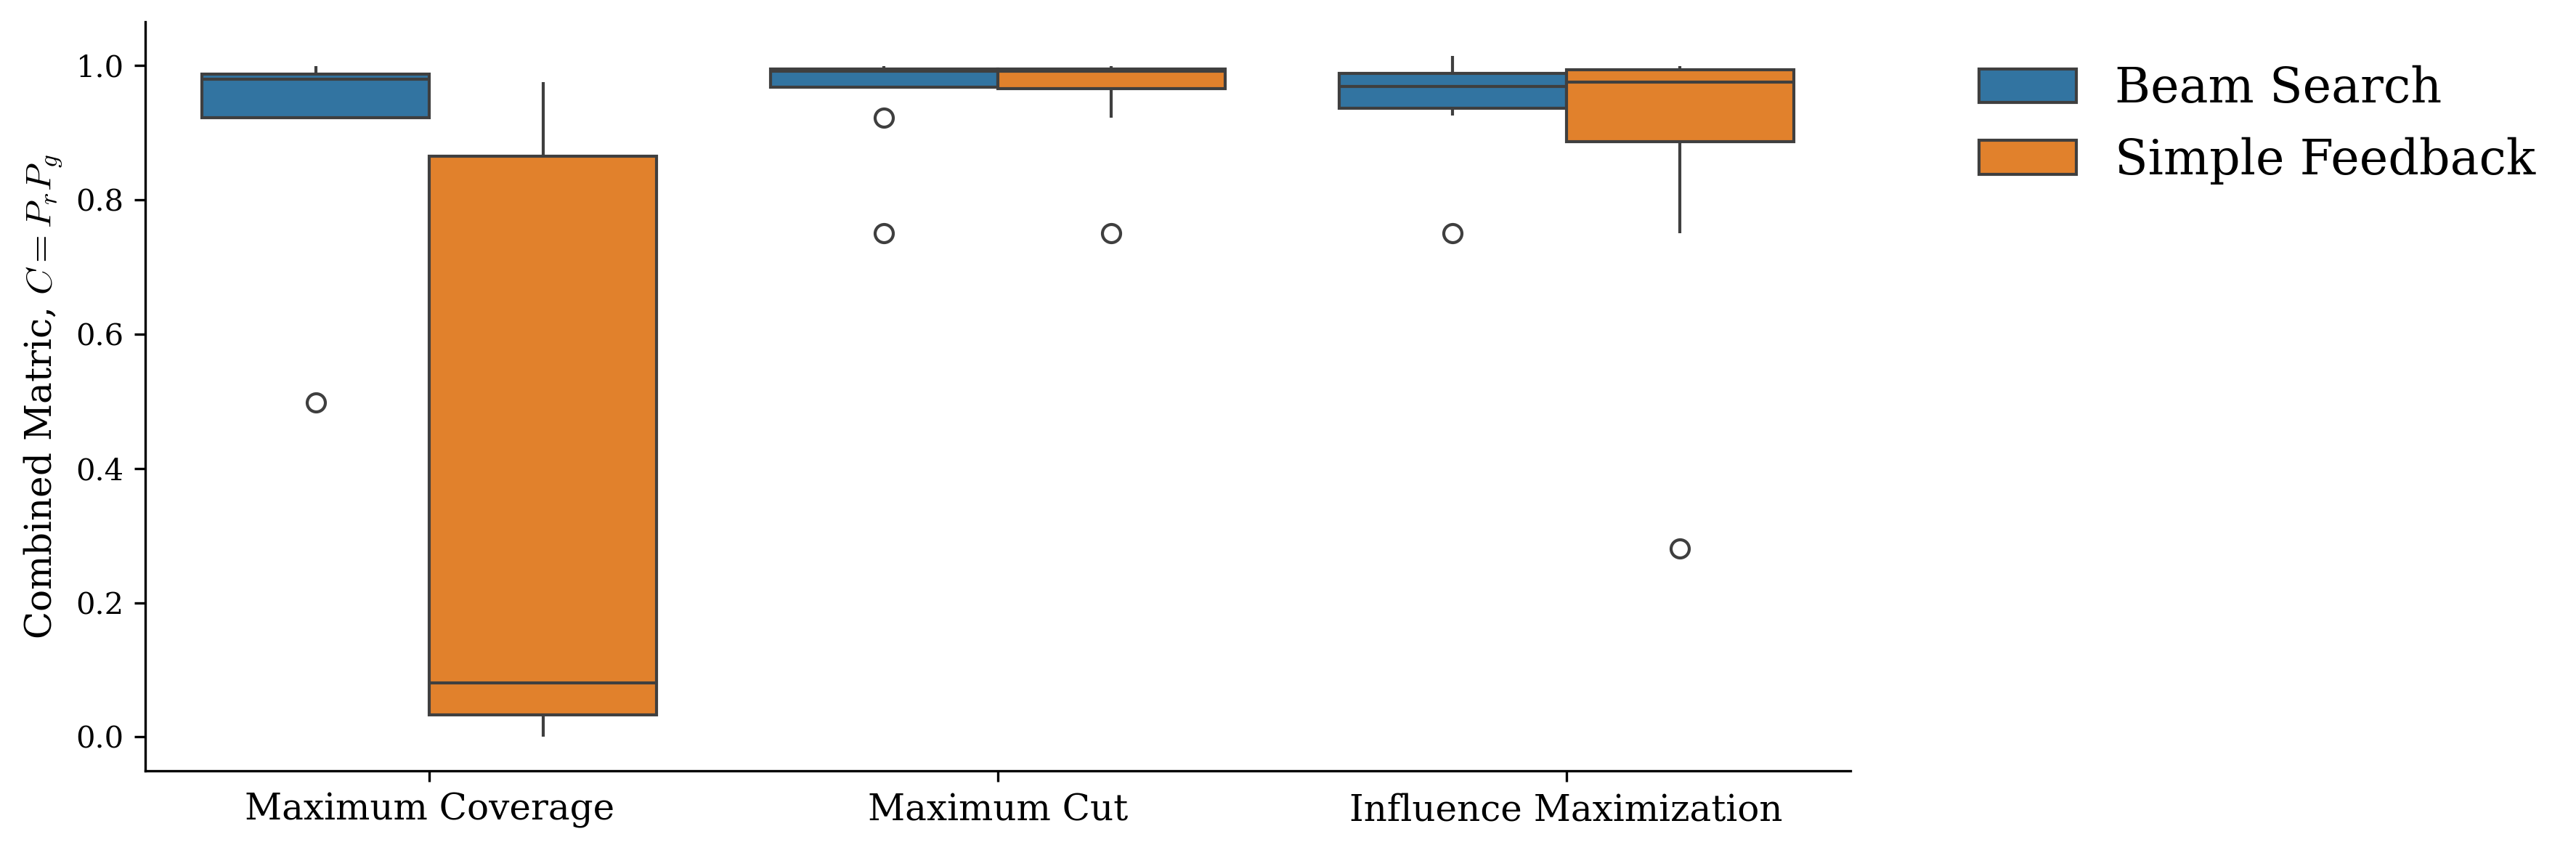

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os

def load_from_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

data_dict = {}

problems = [
    'Maximum Coverage',
    'Maximum Cut',
    'Influence Maximization',

]

datasets = ['Facebook', 'DBLP', 'Deezer', 'Slashdot', 'Wiki', 'Twitter', 'YouTube', 'Skitter']
methods = ['Beam Search', 'Simple Feedback']

# --- Load data ---
for problem in problems:
    data_dict[problem] = {}

    for method in methods:
        data_dict[problem][method] = {}

        for dataset in datasets:
            try:
                if method == 'Beam Search':
                    path = f'{problem}/{dataset}/results/{dataset}.pkl'
                else:
                    path = f'simple_feedback/{problem}/{dataset}/results/{dataset}.pkl'

                if not os.path.exists(path):
                    continue

                results = load_from_pickle(path)
                ratio = float(results['Ratio'].iloc[0])
                size = float(results['Size Reduction'].iloc[0])
                combined = ratio * size

                data_dict[problem][method][dataset] = {
                    "P_r": round(ratio, 4),
                    "P_g": round(size, 4),
                    "C": round(combined, 4)
                }
            except Exception:
                continue


# --- Convert everything into a single DataFrame ---
rows = []
for problem, algos in data_dict.items():
    for algo, datasets in algos.items():
        for dataset, vals in datasets.items():
            if "C" in vals:
                rows.append({
                    "Problem": problem,
                    "Algorithm": algo,
                    "Dataset": dataset,
                    "C": vals["C"]
                })

df = pd.DataFrame(rows)

# --- Plot: boxplot of C across problems ---
plt.figure(figsize=(12, 4), dpi=300)
sns.boxplot(data=df, x="Problem", y="C", hue="Algorithm",showcaps=False)

plt.xlabel("", fontsize=20)
plt.ylabel("Combined Matric, $C =P_rP_g$", fontsize=12)
plt.xticks(fontsize=12)
plt.legend( bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize= 16)

plt.tight_layout()
sns.despine()
plt.savefig("method_comparison_boxplot.pdf", bbox_inches='tight', dpi=500)
plt.show()




In [2]:
import os
import pandas as pd

def generate_stacked_problem_table_filtered(base_folder="multibudget", problems=None, metric="Ratio"):
    if problems is None:
        problems = [
            # "Maximum Coverage",
            # "Maximum Cut",
            # "Influence Maximization",
            "Maximum Coverage Weighted",
            "Maximum Cut Weighted",
            "Influence Maximization Weighted"
        ]

    # Only include these datasets in this specific order
    dataset_order = ["Facebook", "Wiki", "Deezer", "Slashdot", "Twitter", "DBLP", "YouTube", "Skitter"]

    all_data = []

    for problem in problems:
        problem_folder = os.path.join(base_folder, problem)
        if not os.path.exists(problem_folder):
            print(f"Skipping {problem}, folder not found.")
            continue

        rows = []
        for root, _, files in os.walk(problem_folder):
            for file in files:
                if file.endswith(".pkl"):
                    df = pd.read_pickle(os.path.join(root, file))
                    df["Problem"] = problem
                    rows.append(df)

        if not rows:
            print(f"No data found for {problem}.")
            continue

        df_all = pd.concat(rows, ignore_index=True)
        df_all = df_all[["Problem", "Dataset", "Budget", metric]]
        all_data.append(df_all)

    if not all_data:
        print("No data found for any problem.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)

    # Filter and preserve dataset order
    combined_df = combined_df[combined_df["Dataset"].isin(dataset_order)]
    combined_df["Dataset"] = pd.Categorical(combined_df["Dataset"], categories=dataset_order, ordered=True)

    budgets = sorted(combined_df["Budget"].unique())

    # Build LaTeX table
    latex_lines = []
    latex_lines.append("\\begin{table}[ht]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{{metric} results for all problems}}")
    latex_lines.append(f"\\label{{tab:all_problems_{metric.lower()}}}")
    latex_lines.append("\\begin{tabular}{l" + "c" * len(budgets) + "}")
    latex_lines.append("\\toprule")

    for problem in problems:
        df_problem = combined_df[combined_df["Problem"] == problem]
        if df_problem.empty:
            continue

        # Pivot table per problem
        pivot_df = df_problem.pivot_table(
            index="Dataset", columns="Budget", values=metric, aggfunc="mean"
        )
        pivot_df = pivot_df.reindex(dataset_order)  # enforce order
        pivot_df = pivot_df[sorted(pivot_df.columns)]
        pivot_df = pivot_df.round(4)

        # Problem title spanning all columns
        latex_lines.append(f"\\multicolumn{{{len(budgets)+1}}}{{c}}{{\\textbf{{{problem}}}}} \\\\")
        latex_lines.append("\\midrule")
        latex_lines.append("\\textbf{Dataset} & " + " & ".join(str(b) for b in budgets) + " \\\\")
        latex_lines.append("\\midrule")

        # Dataset rows
        for dataset, row in pivot_df.iterrows():
            if dataset not in dataset_order:
                continue
            row_values = " & ".join(f"{v:.4f}" if pd.notna(v) else "-" for v in row.values)
            latex_lines.append(f"{dataset} & {row_values} \\\\")

        latex_lines.append("\\midrule")

    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    latex_str = "\n".join(latex_lines)

    print(latex_str)


# Run
generate_stacked_problem_table_filtered()


Skipping Influence Maximization Weighted, folder not found.
\begin{table}[ht]
\centering
\caption{Ratio results for all problems}
\label{tab:all_problems_ratio}
\begin{tabular}{lcccccc}
\toprule
\multicolumn{7}{c}{\textbf{Maximum Coverage Weighted}} \\
\midrule
\textbf{Dataset} & 1 & 10 & 25 & 50 & 75 & 100 \\
\midrule
Facebook & 1.0000 & 1.0000 & 1.0000 & 0.9900 & 0.9712 & 0.9771 \\
Wiki & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
Deezer & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
Slashdot & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
Twitter & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
DBLP & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
YouTube & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
Skitter & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 \\
\midrule
\multicolumn{7}{c}{\textbf{Maximum Cut Weighted}} \\
\midrule
\textbf{Dataset} & 1 & 10 & 25 & 50 & 75 & 100 \\
\midrule
Facebook & 1.0000 & 1.0000 & 1.000

/tmp/ipykernel_499132/1217161020.py:69: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df_problem.pivot_table(
/tmp/ipykernel_499132/1217161020.py:69: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df_problem.pivot_table(


# Runtime

✅ Bar plot saved as PDF: runtime/Maximum Coverage Weighted_runtime_barplot.pdf


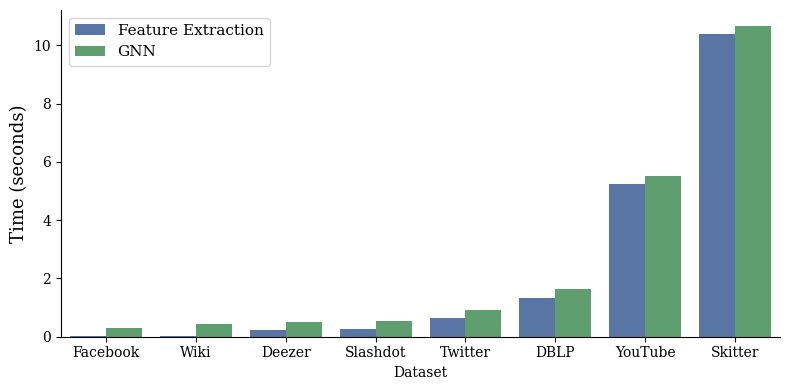

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_runtime_bar(problem, base_folder="runtime"):
    problem_folder = os.path.join(base_folder, problem)
    all_data = []

    # Load all pickles named 'LLM2Prune'
    for root, _, files in os.walk(problem_folder):
        for file in files:
            if "LLM2Prune" in file:
                df = pd.read_pickle(os.path.join(root, file))
                df["Problem"] = problem
                all_data.append(df)

    if not all_data:
        print(f"❌ No runtime data found for {problem}")
        return

    # Combine all datasets
    df_all = pd.concat(all_data, ignore_index=True)
    df_all = df_all[["Dataset", "Feature Extraction Time", "TimeToPrune"]]

    # Melt for grouped barplot
    df_melted = df_all.melt(id_vars="Dataset", var_name="Phase", value_name="Time (s)")

    # Ensure consistent order of datasets
    dataset_order = ["Facebook", "Wiki", "Deezer", "Slashdot", "Twitter", "DBLP", "YouTube", "Skitter"]
    df_melted["Dataset"] = pd.Categorical(df_melted["Dataset"], categories=dataset_order, ordered=True)
    df_melted = df_melted.sort_values("Dataset")

    # Define hue order and colors (must match!)
    hue_order = ["Feature Extraction Time", "TimeToPrune"]
    colors = ["#4C72B0", "#55A868"]  # blue, green

    # Plot
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(
        data=df_melted,
        x="Dataset",
        y="Time (s)",
        hue="Phase",
        hue_order=hue_order,
        palette=colors
    )

    # plt.xlabel("Dataset", fontsize=13)
    plt.ylabel("Time (seconds)", fontsize=13)

    # ✅ Legend with correct color-label mapping
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles,
        ["Feature Extraction", "GNN"],
        title="",
        loc="upper left",
        fontsize=11
    )

    plt.tight_layout()
    sns.despine()

    # ✅ Save as PDF
    out_path = os.path.join(base_folder, f"{problem}_runtime_barplot.pdf")
    plt.savefig(out_path, dpi=300, bbox_inches="tight", format="pdf")

    print(f"✅ Bar plot saved as PDF: {out_path}")

    # ✅ Show interactively
    plt.show()


# Example run
plot_runtime_bar("Maximum Coverage Weighted")
